# Prior and random-effects sensitivity

The reported model uses Normal(0, 2.5) on the population effects, half-Normal(1) on the
by-participant scales, and uncorrelated random effects on all seven terms. With 11 and 10
participants those choices do real work, so this notebook refits the colour x medication interaction
under alternatives:

| Specification | Change |
|---|---|
| reported | Normal(0, 2.5), half-Normal(1), uncorrelated, 7 slopes |
| wide priors | Normal(0, 10), half-Normal(2.5) |
| tight priors | Normal(0, 1), half-Normal(0.5) |
| correlated | LKJ(2) correlation across the 7 by-participant effects |
| reduced random effects | slopes only on intercept, colour, medication, colour x medication |
| intercept only | random intercept, no random slopes (known to be anti-conservative; included as a reference) |

The last row is there to show what dropping random slopes does, which is the specification that
produced the original overconfident result.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
import pymc as pm

from config import dir_config
from src.utils import classification_utils
from src.utils.mcmc_cache import FIT_SETTINGS, TERMS, build_design, prepare_trials, rhat

processed_dir = Path(dir_config.data.processed)
filtered_data = pd.read_csv(processed_dir / "processed_all_data_accu_60_filtered.csv", index_col=None)
metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv", index_col=None)
subjects_map, _ = classification_utils.get_subject_classification_ids(metadata)
OUTPUT_DIR = (Path.cwd().parent / "outputs").resolve(); OUTPUT_DIR.mkdir(exist_ok=True)

SUBTYPES = {"tremor": "tremor_dominant", "bradykinetic": "bradykinesia_dominant"}
COL_MED = TERMS.index("col:med")
RE_SUBSETS = {"full": list(range(len(TERMS))),
              "reduced": [TERMS.index(t) for t in ["intercept", "col", "med", "col:med"]],
              "intercept": [TERMS.index("intercept")]}


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


In [3]:
def fit(subset, beta_sd=2.5, re_sd=1.0, re_subset="full", correlated=False, seed=0):
    design, outcomes, index, participants = build_design(subset)
    keep = RE_SUBSETS[re_subset]
    re_design = design[:, keep]
    n_re = len(keep)
    with pm.Model():
        population = pm.Normal("beta", 0, beta_sd, shape=design.shape[1])
        if correlated:
            chol, _, _ = pm.LKJCholeskyCov("chol", n=n_re, eta=2.0,
                                           sd_dist=pm.HalfNormal.dist(re_sd), compute_corr=True)
            z = pm.Normal("z_u", 0, 1, shape=(n_re, len(participants)))
            u = pm.math.dot(chol, z).T
        else:
            scale = pm.HalfNormal("sd_u", re_sd, shape=n_re)
            z = pm.Normal("z_u", 0, 1, shape=(len(participants), n_re))
            u = z * scale
        eta = pm.math.sum(design * population, axis=1) + pm.math.sum(re_design * u[index], axis=1)
        pm.Bernoulli("obs", logit_p=eta, observed=outcomes)
        return pm.sample(FIT_SETTINGS["draws"], tune=FIT_SETTINGS["tune"], chains=FIT_SETTINGS["chains"],
                         cores=FIT_SETTINGS["chains"], target_accept=0.95, random_seed=seed, progressbar=False)


SPECS = {"reported": {}, "wide priors": dict(beta_sd=10.0, re_sd=2.5),
         "tight priors": dict(beta_sd=1.0, re_sd=0.5), "correlated": dict(correlated=True),
         "reduced random effects": dict(re_subset="reduced"), "intercept only": dict(re_subset="intercept")}

rows = []
for subtype, key in SUBTYPES.items():
    subset = prepare_trials(filtered_data, subjects_map[key])
    for label, kwargs in SPECS.items():
        idata = fit(subset, **kwargs)
        beta = idata.posterior["beta"].values
        draws = beta[..., COL_MED].ravel()
        low, high = np.percentile(draws, [2.5, 97.5])
        rows.append({"subtype": subtype, "specification": label, "col:med": draws.mean(), "SD": draws.std(),
                     "2.5%": low, "97.5%": high, "P(> 0)": (draws > 0).mean(),
                     "divergences": int(idata.sample_stats["diverging"].values.sum()),
                     "max r_hat": max(rhat(beta[..., k]) for k in range(beta.shape[-1]))})
        print(f"{subtype:13s} {label:24s} {draws.mean():+.3f} [{low:+.3f}, {high:+.3f}] "
              f"P(>0)={(draws > 0).mean():.3f}  div={rows[-1]['divergences']}")

sensitivity = pd.DataFrame(rows).set_index(["subtype", "specification"])
sensitivity.round(3)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 167 seconds.
Initializing NUTS using jitter+adapt_diag...


tremor        reported                 +0.530 [-0.016, +1.064] P(>0)=0.971  div=0


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 185 seconds.
Initializing NUTS using jitter+adapt_diag...


tremor        wide priors              +0.542 [-0.038, +1.135] P(>0)=0.965  div=0


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 156 seconds.
Initializing NUTS using jitter+adapt_diag...


...

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 80 seconds.
Initializing NUTS using jitter+adapt_diag...


bradykinetic  reduced random effects   +0.011 [-0.537, +0.555] P(>0)=0.525  div=0


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 47 seconds.


bradykinetic  intercept only           +0.018 [-0.153, +0.186] P(>0)=0.589  div=0


col:med     SD   2.5%  97.5%  P(> 0)  \
subtype      specification                                                  
tremor       reported                  0.530  0.279 -0.016  1.064   0.971   
             wide priors               0.542  0.299 -0.038  1.135   0.965   
             tight priors              0.507  0.240  0.015  0.959   0.978   
             correlated                0.520  0.302 -0.065  1.132   0.959   
             reduced random effects    0.462  0.245 -0.021  0.927   0.970   
             intercept only            0.439  0.083  0.276  0.601   1.000   
bradykinetic reported                  0.054  0.285 -0.512  0.623   0.580   
             wide priors               0.053  0.317 -0.572  0.677   0.577   
             tight priors              0.043  0.241 -0.426  0.526   0.570   
             correlated                0.035  0.281 -0.533  0.594   0.556   
             reduced random effects    0.011  0.274 -0.537  0.555   0.525   
             intercept only            0.018  0.085 -0.153  0.186   0.588   

                                     divergences  max r_hat  
subtype      specification                                   
tremor       reported                          0      1.004  
             wide priors                       0      1.006  
             tight priors                      0      1.004  
             correlated                        0      1.002  
             reduced random effects            0      1.006  
             intercept only                    0      1.008  
bradykinetic reported                          0      1.006  
             wide priors                       0      1.005  
             tight priors                      0      1.008  
             correlated                        0      1.005  
             reduced random effects            0      1.004  
             intercept only                    0      1.002

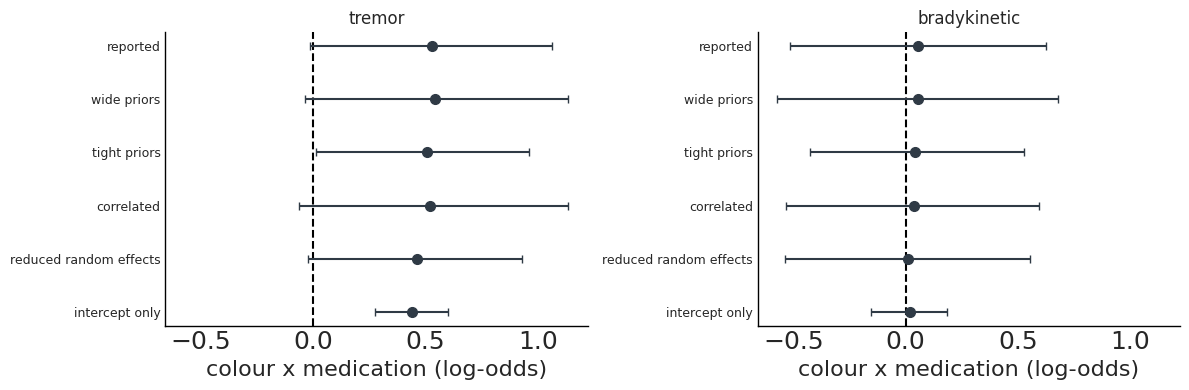

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, subtype in zip(axes, SUBTYPES):
    block = sensitivity.loc[subtype].iloc[::-1]
    y = np.arange(len(block))
    ax.axvline(0, color="k", ls="--", lw=1.5)
    ax.errorbar(block["col:med"], y, xerr=[block["col:med"] - block["2.5%"], block["97.5%"] - block["col:med"]],
                ls="", marker="o", ms=7, color="#2F3A45", capsize=3, lw=1.5)
    ax.set_yticks(y); ax.set_yticklabels(block.index, fontsize=9)
    ax.set_xlabel("colour x medication (log-odds)"); ax.set_title(subtype, fontsize=12)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "prior_re_sensitivity.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "prior_re_sensitivity.png", dpi=200, bbox_inches="tight"); plt.show()
sensitivity.to_csv(OUTPUT_DIR / "prior_re_sensitivity.csv")
